In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
X=df[['Age','EstimatedSalary']]
y=df['Purchased']

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
standard=StandardScaler()
X_train=standard.fit_transform(X_train)
X_test=standard.transform(X_test)

In [9]:
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [10]:
y_pred=lg.predict(X_test)

In [11]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8625
[[50  2]
 [ 9 19]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



In [12]:
from sklearn.model_selection import GridSearchCV

In [13]:
# 1. Define the base model
base_model = LogisticRegression(max_iter=1000, random_state=42)

In [14]:
# 2. Define the hyperparameter grid
param_grid = [
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2', None],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
    }
]

In [15]:
# 3. Instantiate GridSearchCV (5-fold cross-validation)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross validation
    scoring='accuracy',    # Metric to optimize
    n_jobs=-1,             # Use all CPU cores
    verbose=1
)

In [17]:
# 4. Fit Grid Search on training data ONLY
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'penalty': ['l1', 'l2'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'penalty': ['l2', None], 'solver': ['lbfgs']}],
             scoring='accuracy', verbose=1)

In [18]:
# 5. Output the best hyperparameters and cross-validation score
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8313


In [20]:
# 6. Evaluate the best model on the unseen Test Set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report
print(f"\nTuned Test Set Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))


Tuned Test Set Accuracy: 0.8875

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [24]:
# 1. Linear SVM (Draws a straight line, similar to Logistic Regression)
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

print(f"Linear SVM Test Accuracy: {accuracy_score(y_test, y_pred_linear):.4f}")

Linear SVM Test Accuracy: 0.8625


In [25]:
# 2. Non-Linear Kernel SVM (RBF Kernel - Curves around data points)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

print(f"RBF Kernel SVM Test Accuracy: {accuracy_score(y_test, y_pred_rbf):.4f}")

RBF Kernel SVM Test Accuracy: 0.9250


In [27]:
# Create a mesh grid of points
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

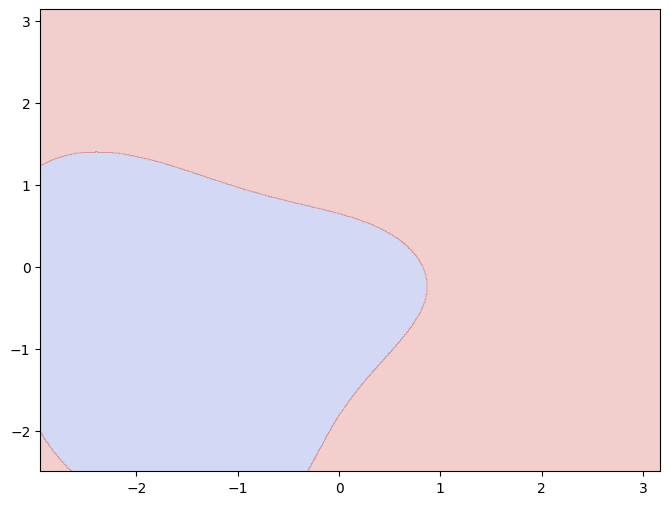

In [28]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(
    X1, X2,
    svm_rbf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.25, cmap=plt.cm.coolwarm
)

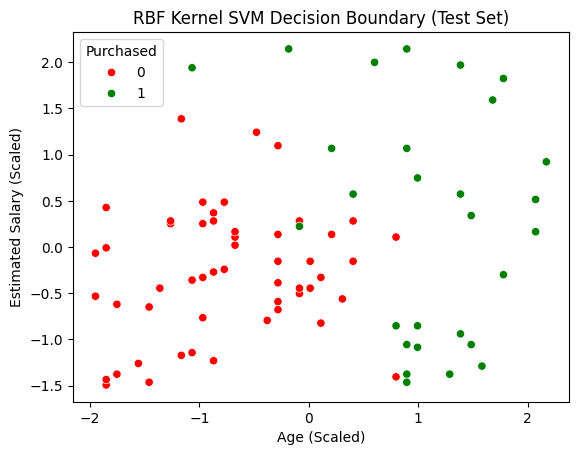

In [29]:
# Scatter plot test points
sns.scatterplot(x=X_set[:, 0], y=X_set[:, 1], hue=y_set, palette=['red', 'green'])
plt.title('RBF Kernel SVM Decision Boundary (Test Set)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.show()